# Импорты 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 6)

# Функции

## Gini

In [69]:
def gini_score(y_true, y_proba):
    return 2 * roc_auc_score(y_true, y_proba) - 1


## Фун-я чистки выбросов

In [3]:
def iqr_cleaner(df: pd.DataFrame, columns: list | np.ndarray) -> tuple[pd.DataFrame, pd.DataFrame]: 
    '''
        Возвращает очищенный фрейм clean_df и фрейм со статистикой очищенных выбросов: report_df
    '''
    df_clean = df.copy()
    results = []
    for col in columns: 
        if col in df_clean.columns: 
            Q1 = df_clean[col].quantile(0.25) 
            Q3 = df_clean[col].quantile(0.75) 
            IQR = Q3 - Q1 
            
            lower_bound = Q1 - 3 * IQR 
            upper_bound = Q3 + 3 * IQR 
            
            outliers_before = len(df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)])
            min_before = df_clean[col].min()
            max_before = df_clean[col].max()
            
            df_clean.loc[df_clean[col] < lower_bound, col] = lower_bound
            df_clean.loc[df_clean[col] > upper_bound, col] = upper_bound
            
            outliers_after = len(df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)])
            min_after = df_clean[col].min()
            max_after = df_clean[col].max()
            

            results.append({
                'колонка': col,
                'выбросы_до': outliers_before,
                'выбросы_после': outliers_after,
                'очищено': outliers_before - outliers_after,
                'нижняя_граница': lower_bound,
                'верхняя_граница': upper_bound,
                'мин_до': min_before,
                'макс_до': max_before,
                'мин_после': min_after,
                'макс_после': max_after,
                'Q1': Q1,
                'Q3': Q3,
                'IQR': IQR
            })
            
    report_df = pd.DataFrame(results)
    return df_clean, report_df
            

## Функция my_time_train_valid_test_split

In [4]:
def my_time_train_valid_test_split(df: pd.DataFrame, target_name: str = 'IsBadBuy', date_column: str = 'PurchDate'):
    df_sorted = df.sort_values(date_column).reset_index(drop=True)

    total_len = len(df_sorted)
    train_end = total_len // 3
    valid_end = 2 * (total_len // 3)

    X_sorted = df_sorted.drop(target_name, axis=1)
    y_sorted = df_sorted[target_name]

    X_train, y_train = X_sorted.iloc[:train_end], y_sorted.iloc[:train_end]
    X_valid, y_valid = X_sorted.iloc[train_end:valid_end], y_sorted.iloc[train_end:valid_end]
    X_test, y_test = X_sorted.iloc[valid_end:], y_sorted.iloc[valid_end:]

    return X_train, y_train, X_valid, y_valid, X_test, y_test

## Функция get_column_types

In [5]:
def get_column_types(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    ''' 
     Возвращает numeric_col, cat_col
    '''
    numeric = df.select_dtypes(include='number').columns
    categorical = df.select_dtypes(include='object').columns
    return numeric.drop('IsBadBuy'), categorical

# Считывание данных

Описание признаков

<iframe src="https://www.kaggle.com/embed/voluichik/auto-ml-itmo?cellIds=9&kernelSessionId=286204168" height="300" style="margin: 0 auto; width: 100%; max-width: 950px;" frameborder="0" scrolling="auto" title="Auto ML ITMO"></iframe>

In [6]:
df = pd.read_csv('data/training.csv', parse_dates=['PurchDate'])

In [7]:
initially_df_len = df.shape[1]
initially_df_len

34

# EDA

## Получаю базовую предварительную информацию + делю на num/cat columns

In [8]:
df

,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,1,0,2009-12-07,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,...,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,2,0,2009-12-07,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,...,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,3,0,2009-12-07,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,...,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389
3,4,0,2009-12-07,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,...,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630
4,5,0,2009-12-07,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,...,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72978,73010,1,2009-12-02,ADESA,2001,8,MERCURY,SABLE,GS,4D SEDAN GS,...,4836.0,5937.0,NaN,NaN,18111,30212,GA,4200.0,0,993
72979,73011,0,2009-12-02,ADESA,2007,2,CHEVROLET,MALIBU 4C,LS,4D SEDAN LS,...,10151.0,11652.0,NaN,NaN,18881,30212,GA,6200.0,0,1038
72980,73012,0,2009-12-02,ADESA,2005,4,JEEP,GRAND CHEROKEE 2WD V,Lar,4D WAGON LAREDO,...,11831.0,14402.0,NaN,NaN,18111,30212,GA,8200.0,0,1893
72981,73013,0,2009-12-02,ADESA,2006,3,CHEVROLET,IMPALA,LS,4D SEDAN LS,...,10099.0,11228.0,NaN,NaN,18881,30212,GA,7000.0,0,1974


In [9]:
numeric_columns, cat_columns = get_column_types(df)

## Анализ целевой с числовыми признаками

In [10]:
target = df['IsBadBuy']
print(f'Распределение классов:')
print(f'Класс 1 = {round(target[target == 1].count() / len(target), 2)}%\nКласс0 = {round(target[target == 0].count() / len(target), 2)}%')

Распределение классов:
Класс 1 = 0.12%
Класс0 = 0.88%


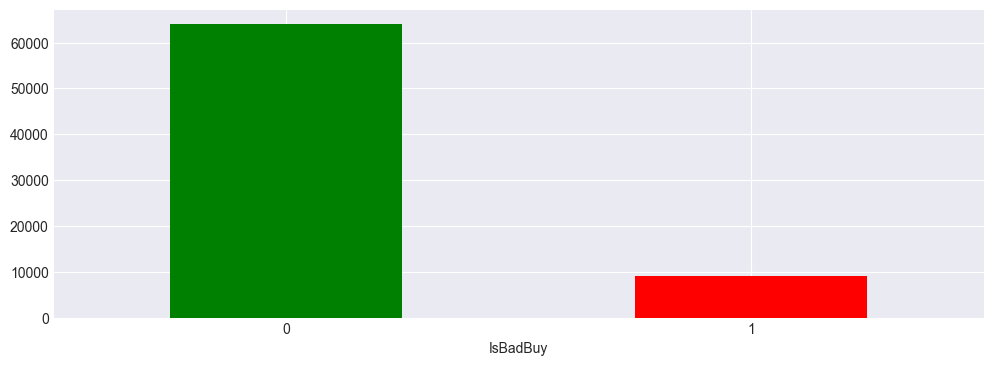

In [11]:
plt.figure(figsize=(12, 4))
df['IsBadBuy'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.xticks(rotation=0)
plt.show()

In [12]:
monthly_stats = df.groupby(df["PurchDate"].dt.to_period("M")).agg({"IsBadBuy": ["sum", "count"]})
monthly_stats.columns = ["bad_count", "total_count"]

In [13]:
monthly_stats["bad_rate"] = (monthly_stats["bad_count"] / monthly_stats["total_count"] * 100)

In [14]:
monthly_stats.index = monthly_stats.index.to_timestamp()

Вывод по графику: присутствует волатильность(изменчивость) доли bad buy в зависимости от месяца. Разница почти в 2 раза между минимумом и максимумом

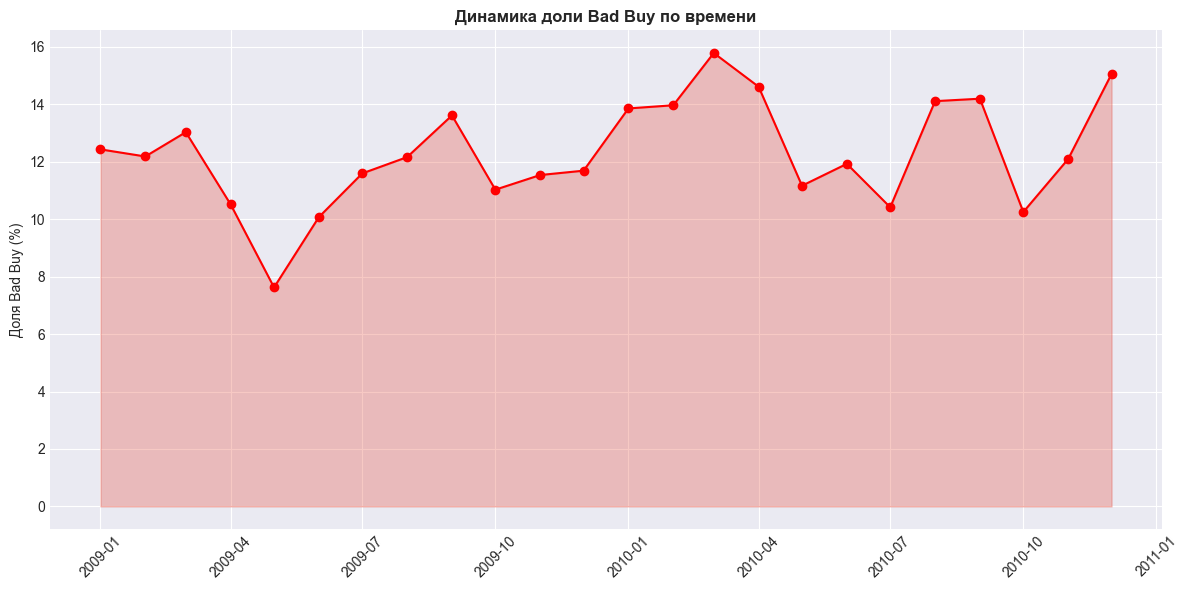

In [15]:
plt.plot(monthly_stats.index, monthly_stats['bad_rate'], c='red', marker='o')
plt.fill_between(monthly_stats.index, monthly_stats["bad_rate"], alpha=0.3, color="#e74c3c")

plt.title("Динамика доли Bad Buy по времени", fontweight="bold")
plt.ylabel("Доля Bad Buy (%)")
plt.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

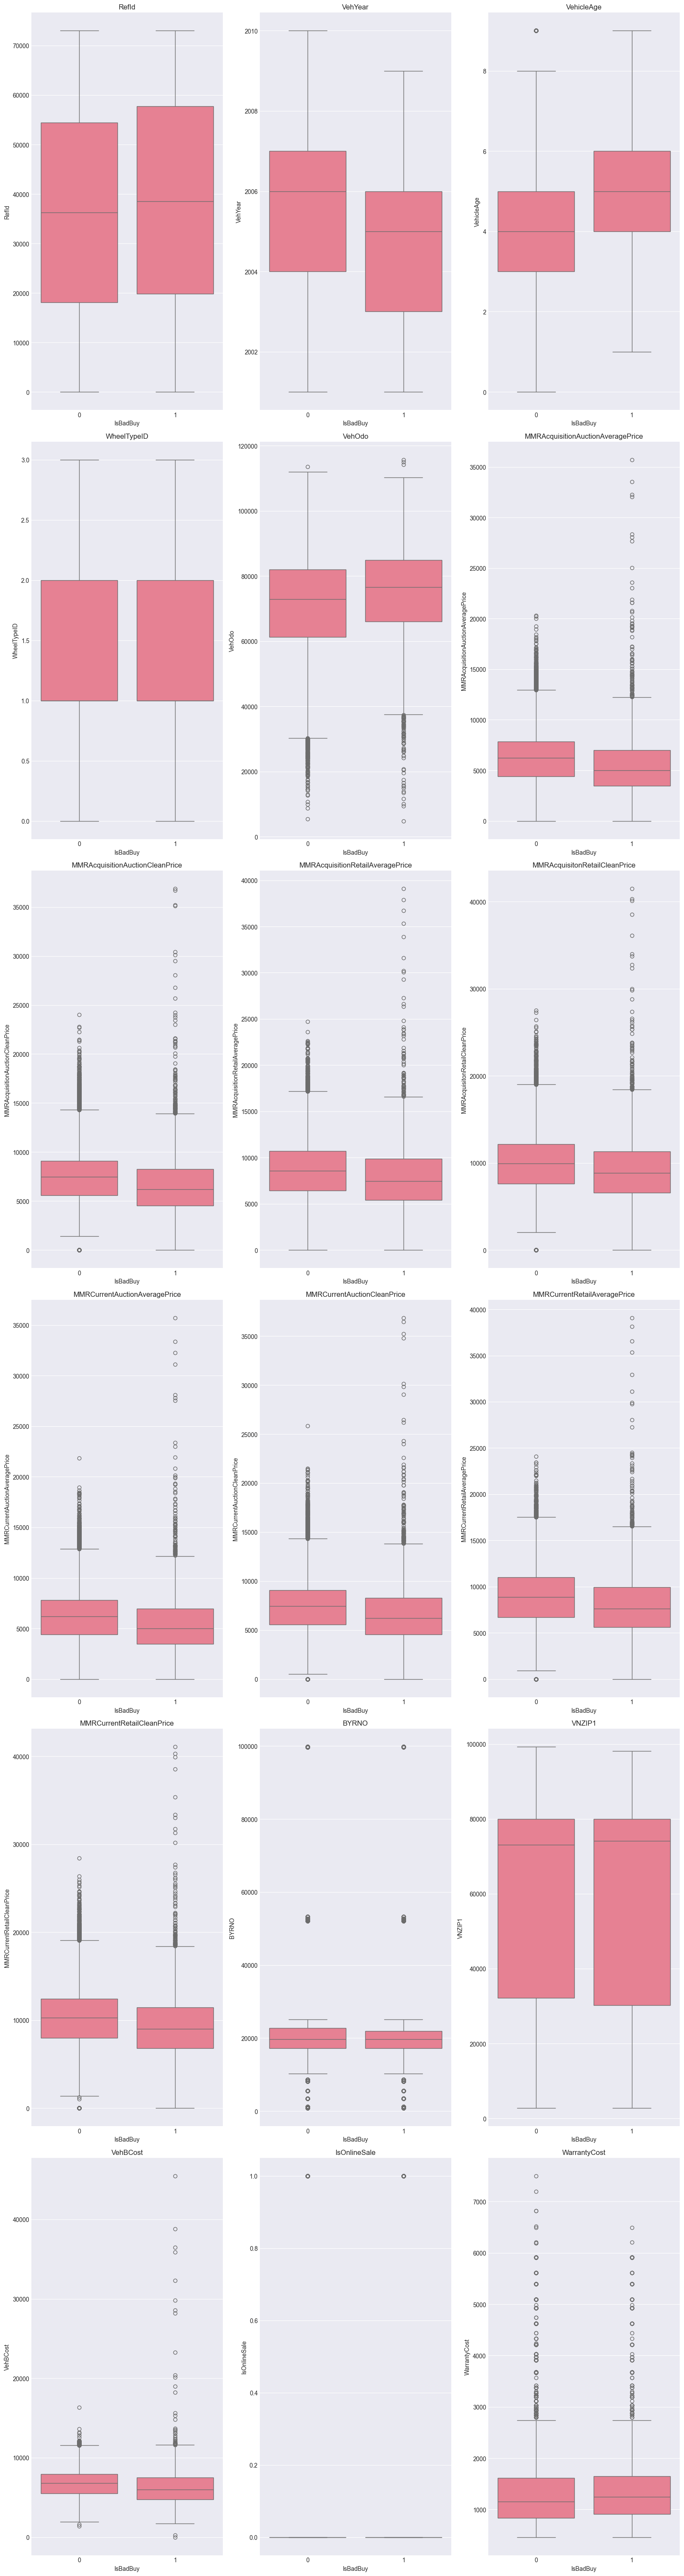

In [16]:
n_cols = 3
n_rows = (len(numeric_columns) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(y=col, x=df['IsBadBuy'].astype('category'), data=df, ax=axes[i])
    axes[i].set_title(f'{col}')
    
plt.tight_layout()
plt.show()

Выводы по боксплотам:
Можно сделать следующие выводы: 
- От года выпуска (VehYear) зависит будет ли покупка плохой (в среднем чем ниже год, тем вероятнее, что покупка будет плохой) 
- Аналогично с возрастом автомобиля (выброс в хорошей покупке можно убрать/заменить граничным значением, так как это можно списать на везение (покупка очень старого автомобиля оказалась хорошей) из реальной жизни можно привести пример хорошей покупки какого-нибудь раритетного коллекционного авто, цель которого быть в коллекции в автопарке, а не применяться по назначению)
- Можно предположить (но не утверждать), что от показателя пробега в км/милях зависит итог покупки 

А дальше неочевидные закономерности:
- В нашем случае у Оценочная цена приобретения на аукционе для автомобиля в среднем состоянии на момент покупки (MMRAcquisitionAuctionAveragePrice) есть сильная переплата при неудачной покупке (нужно будет решить, как работать с этими выбросами). НО в среднем, цена у машин, считающихся плохими, ниже, чем у хороших 
- Аналогично для остальных признаков с MMR 

Данные признаки лучше всего как-то скомбинировать, чтобы получить новый, объясняющий закономерности, признак, способный сократить кол-во признаков 




Тогда можем проверить корреляции между всеми MMR

In [17]:
MMR_frame = df[[col for col in df.columns if col.startswith('MMR')]]

In [18]:
corr_matrix = MMR_frame.corr()

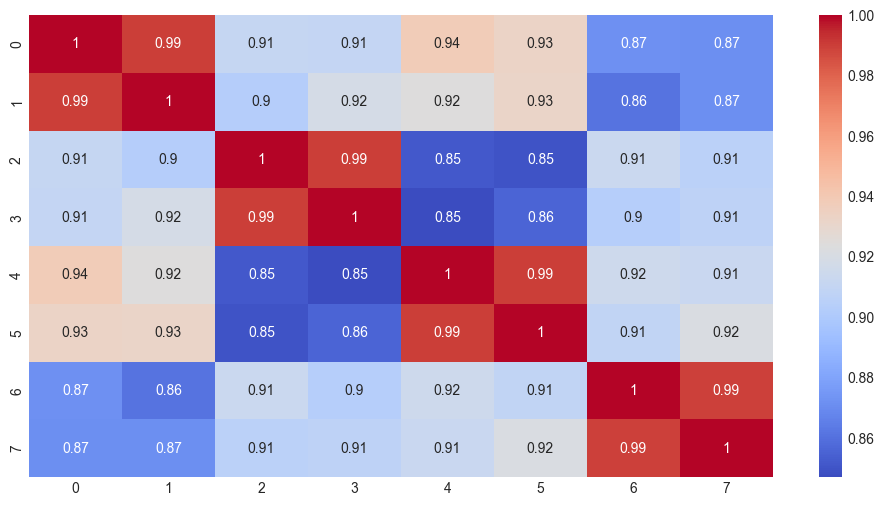

In [19]:
default_cmap = np.zeros_like(corr_matrix)
high_corr_mask = corr_matrix.abs() > 0.5
data_to_show = np.where(high_corr_mask, corr_matrix, np.nan)

sns.heatmap(data_to_show, annot=True, cmap='coolwarm')
plt.show()

Можем сделать вывод, что все признаки ОЧЕНЬ коррелированы между собой и нужно придумать новые комбинации этих признаков

Комбинация признаков и создание новых переменных на основе них будут в следующих шагах по заданию проекта

## Чистка пропусков

In [20]:
print('Пропуски в процентах')
df.isna().sum().sort_values(ascending=False)[:20] / len(df)

Пропуски в процентах


PRIMEUNIT                            0.953153
AUCGUART                             0.953153
WheelType                            0.043490
WheelTypeID                          0.043421
Trim                                 0.032336
MMRCurrentAuctionAveragePrice        0.004316
MMRCurrentRetailCleanPrice           0.004316
MMRCurrentRetailAveragePrice         0.004316
MMRCurrentAuctionCleanPrice          0.004316
MMRAcquisitionAuctionAveragePrice    0.000247
MMRAcquisitionAuctionCleanPrice      0.000247
MMRAcquisitionRetailAveragePrice     0.000247
MMRAcquisitonRetailCleanPrice        0.000247
Transmission                         0.000123
SubModel                             0.000110
Color                                0.000110
Nationality                          0.000069
Size                                 0.000069
TopThreeAmericanName                 0.000069
BYRNO                                0.000000
dtype: float64

Считаю, что все столбцы с кол-вом выбросов больше 50% нужно убрать, а это PRIMEUNIT и AUCGUART

In [21]:
df = df.drop(['PRIMEUNIT', 'AUCGUART'], axis=1)

Столбцы wheelTypeID и WheelType дублируют друг друга, оставляю только один

In [22]:
df.columns

Index(['RefId', 'IsBadBuy', 'PurchDate', 'Auction', 'VehYear', 'VehicleAge',
       'Make', 'Model', 'Trim', 'SubModel', 'Color', 'Transmission',
       'WheelTypeID', 'WheelType', 'VehOdo', 'Nationality', 'Size',
       'TopThreeAmericanName', 'MMRAcquisitionAuctionAveragePrice',
       'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice',
       'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice',
       'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice',
       'MMRCurrentRetailCleanPrice', 'BYRNO', 'VNZIP1', 'VNST', 'VehBCost',
       'IsOnlineSale', 'WarrantyCost'],
      dtype='str')

In [23]:
df.WheelTypeID.unique()

array([ 1.,  2., nan,  3.,  0.])

* Alloy = 1 
* Covers = 2
* Special = 3
* Nan = 0 

In [24]:
df[df['WheelTypeID'].isna()][['IsBadBuy', 'WheelTypeID']]

,IsBadBuy,WheelTypeID
39,1,NaN
41,1,NaN
45,1,NaN
47,1,NaN
49,1,NaN
...,...,...
72915,1,NaN
72924,1,NaN
72933,1,NaN
72959,1,NaN


In [25]:
df.WheelType.unique()

<StringArray>
['Alloy', 'Covers', nan, 'Special']
Length: 4, dtype: str

In [26]:
df['WheelTypeID'] = df['WheelTypeID'].fillna(0)

Также можно удалить незначащие признаки: 
* RefId (id не несет смысловой нагрузки)
* IsOnlineSale (по боксплоту видно, что признак никак не влияет на таргет)
* BYRNO(id покупателя не несет смысловой нагрузки)
* VNZIP(уберем айди почтового адреса, но оставим штат, где был куплен авто VNST)
* WheelType (дублирует WheelTypeID (лучше оставить ID, так как номинальная величина уже закодирована))

In [27]:
df = df.drop(['RefId', 'IsOnlineSale', 'BYRNO', 'VNZIP1', 'WheelType'], axis=1)

In [28]:
numeric_columns, cat_columns = get_column_types(df)

## Замена пропусков и выбросов

In [29]:
df.isna().sum().sort_values(ascending=False)

Trim                                 2360
MMRCurrentRetailCleanPrice            315
MMRCurrentRetailAveragePrice          315
MMRCurrentAuctionCleanPrice           315
MMRCurrentAuctionAveragePrice         315
MMRAcquisitionAuctionAveragePrice      18
MMRAcquisitionRetailAveragePrice       18
MMRAcquisitonRetailCleanPrice          18
MMRAcquisitionAuctionCleanPrice        18
Transmission                            9
SubModel                                8
Color                                   8
Size                                    5
TopThreeAmericanName                    5
Nationality                             5
VNST                                    0
VehBCost                                0
IsBadBuy                                0
PurchDate                               0
VehOdo                                  0
WheelTypeID                             0
Model                                   0
Make                                    0
VehicleAge                        

Все пропуски в MMR решил заполнять медианой, так как на боксплотах можно было заметить выбросы

In [30]:
for col in numeric_columns: 
    df[col] = df[col].fillna(df[col].median())

In [31]:
for col in cat_columns: 
    df[col] = df[col].fillna(df[col].mode()[0])

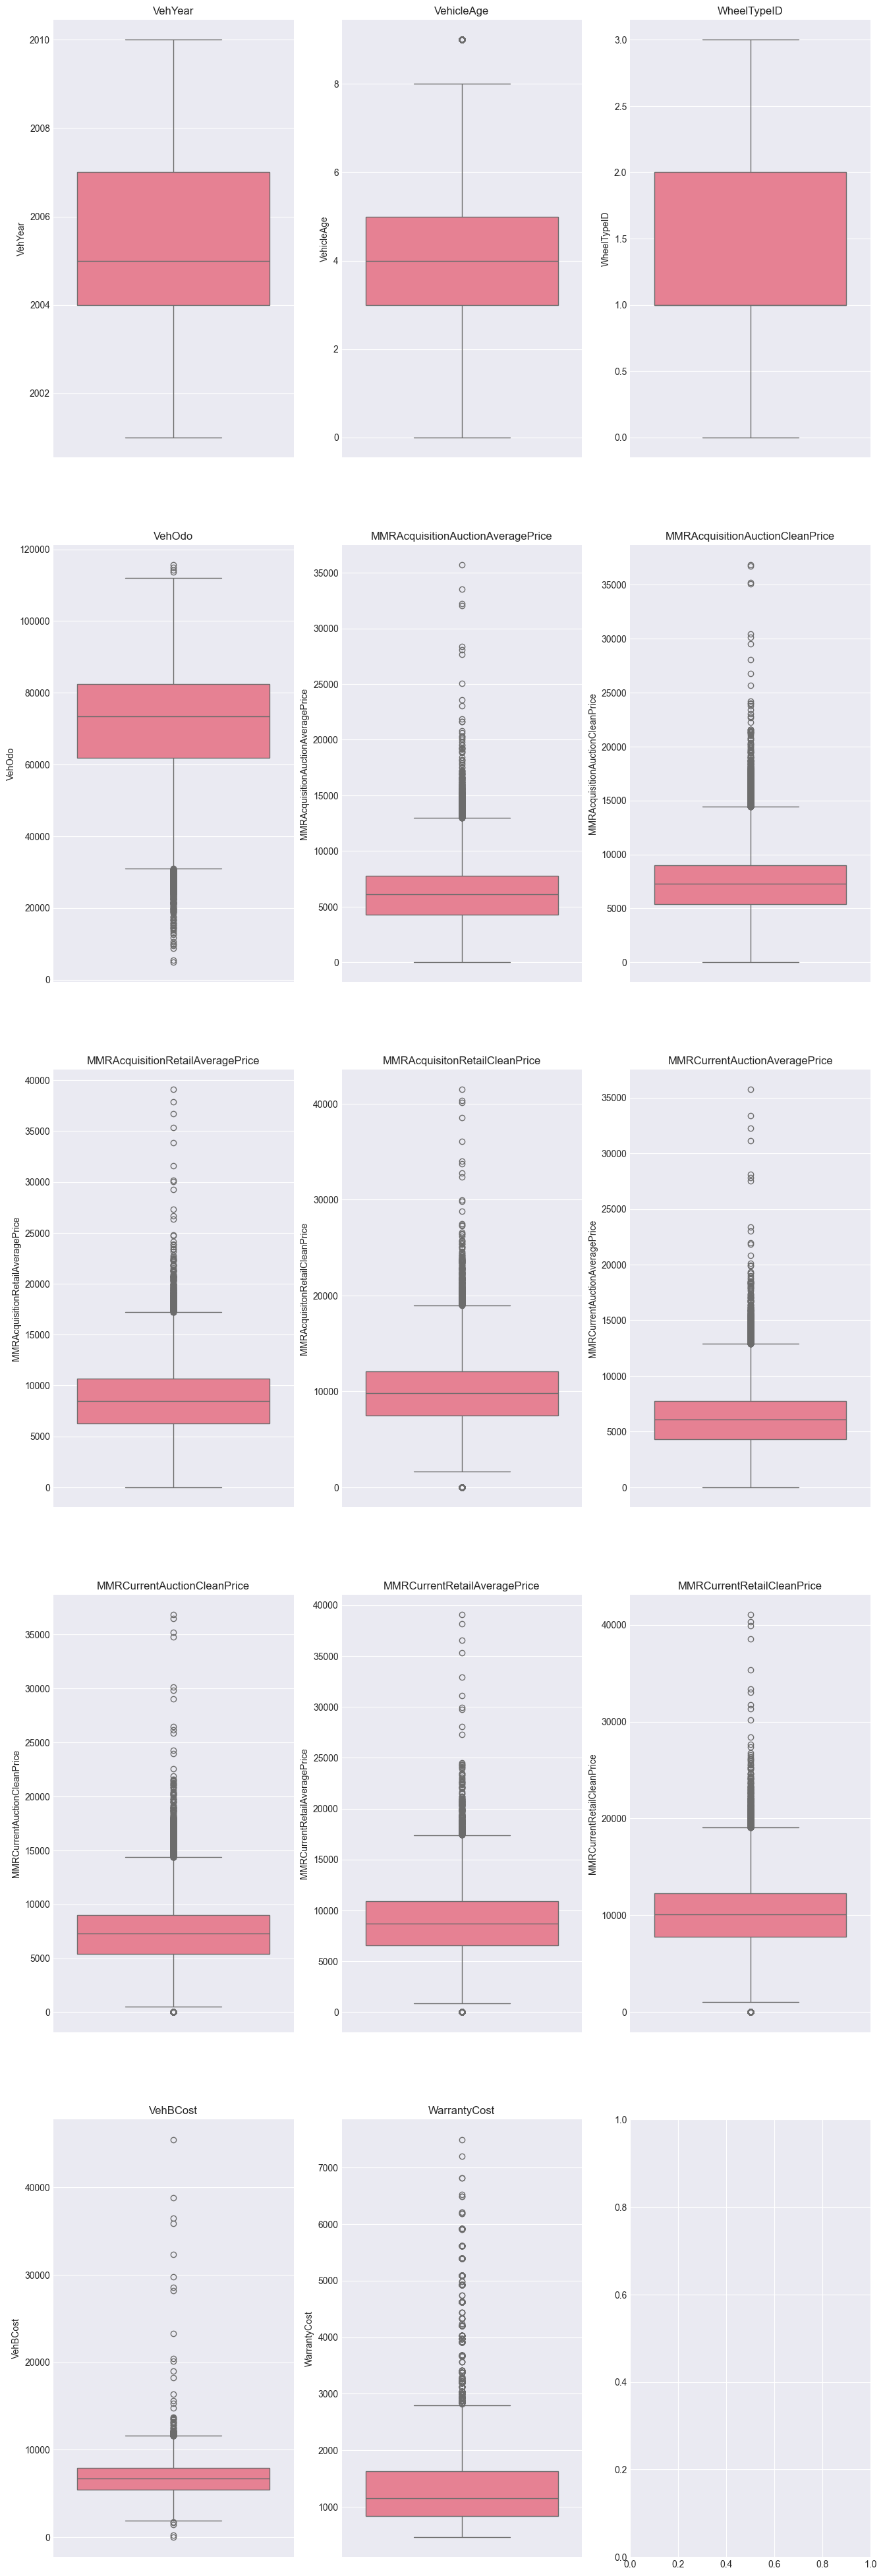

In [32]:
n_cols = 3
n_rows = (len(numeric_columns) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(df[col], ax=axes[i])
    axes[i].set_title(f'{col}')

Почистим только WarrantyCost, хоть и другие столбцы тоже должны быть очищены, но в распределениии IsBadBuy большие значения в других столбцах имеют, на мой взгляд, влияние

In [33]:
df, report_df = iqr_cleaner(df, ['WarrantyCost'])

In [34]:
report_df

,колонка,выбросы_до,выбросы_после,очищено,нижняя_граница,верхняя_граница,мин_до,макс_до,мин_после,макс_после,Q1,Q3,IQR
0,WarrantyCost,466,0,466,-1521.0,3981.0,462,7498,462,3981,837.0,1623.0,786.0


In [35]:
# df, report_df = iqr_cleaner(df, numeric_columns)

## Анализ целевой переменной с категориальными признаками

In [36]:
numeric_columns, cat_columns = get_column_types(df)

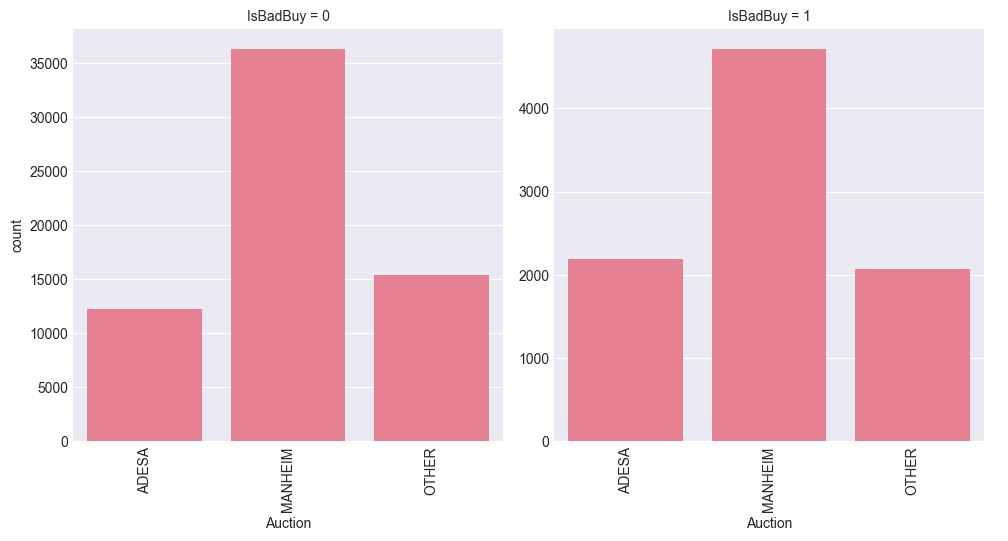

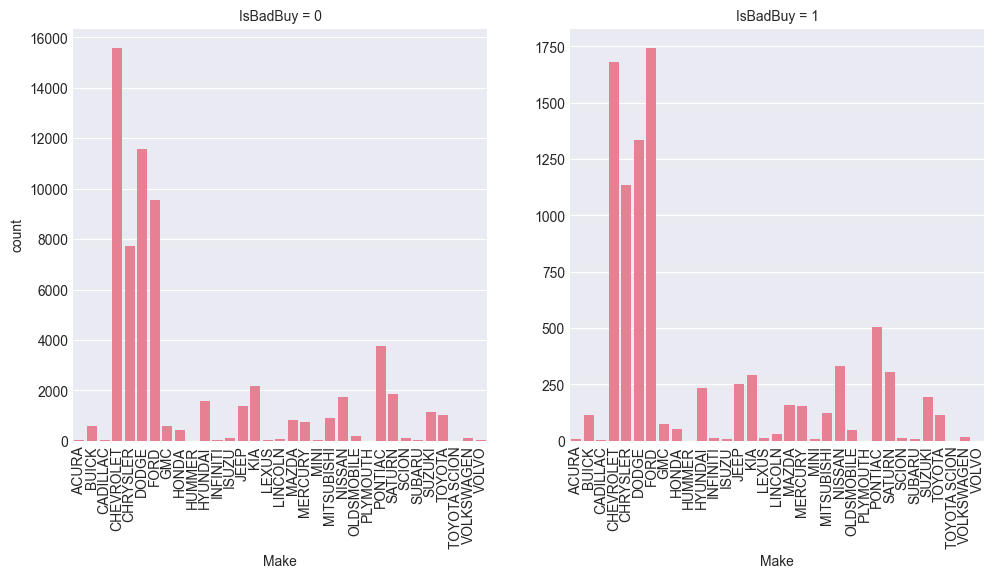

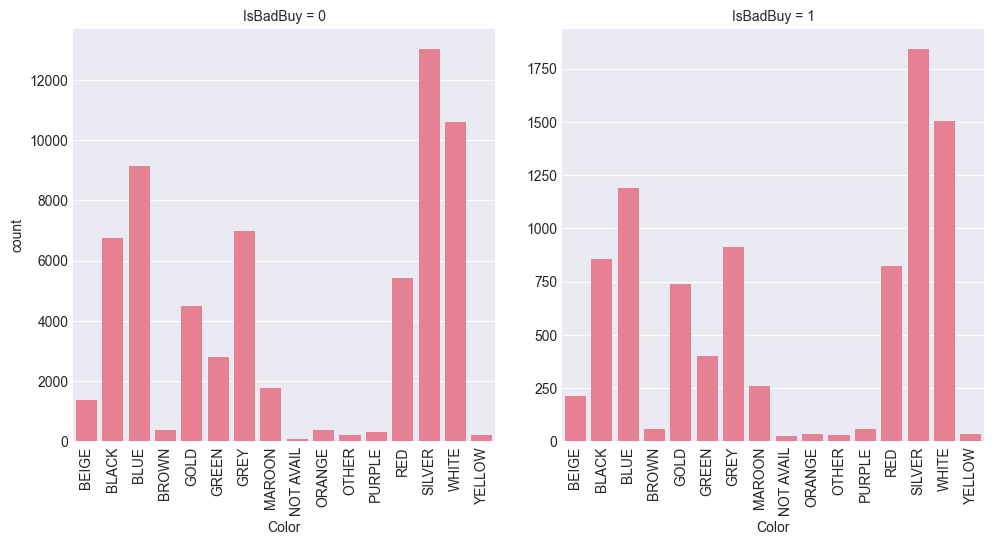

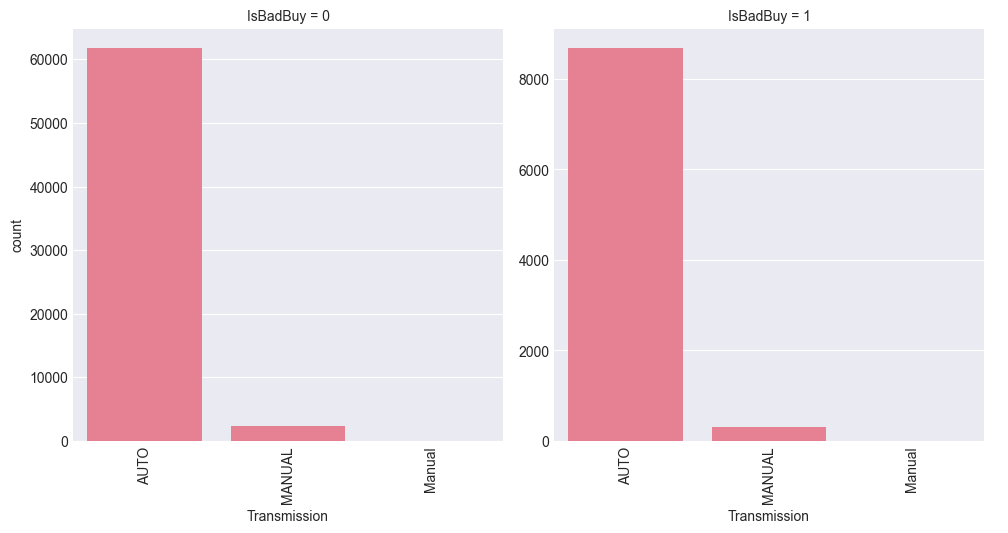

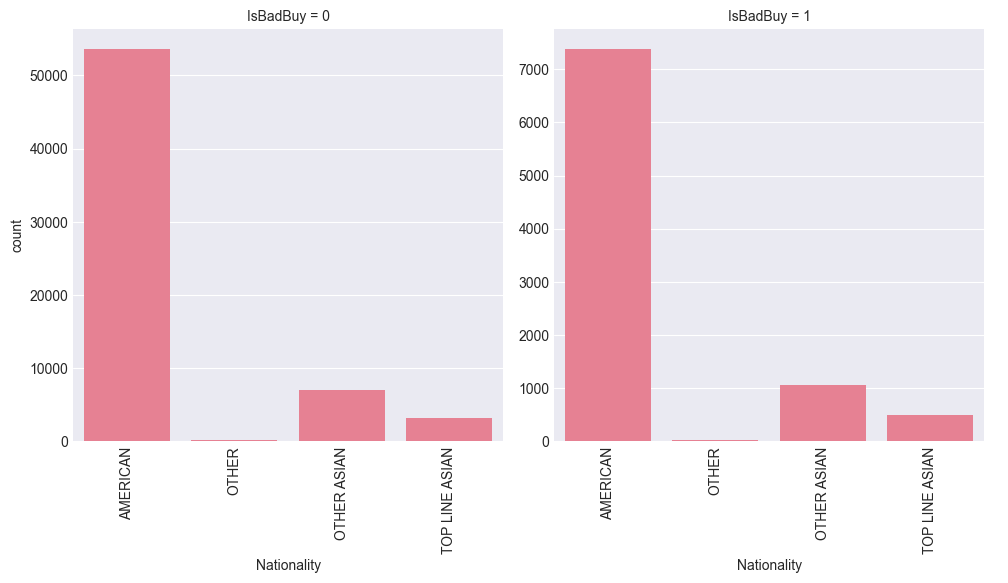

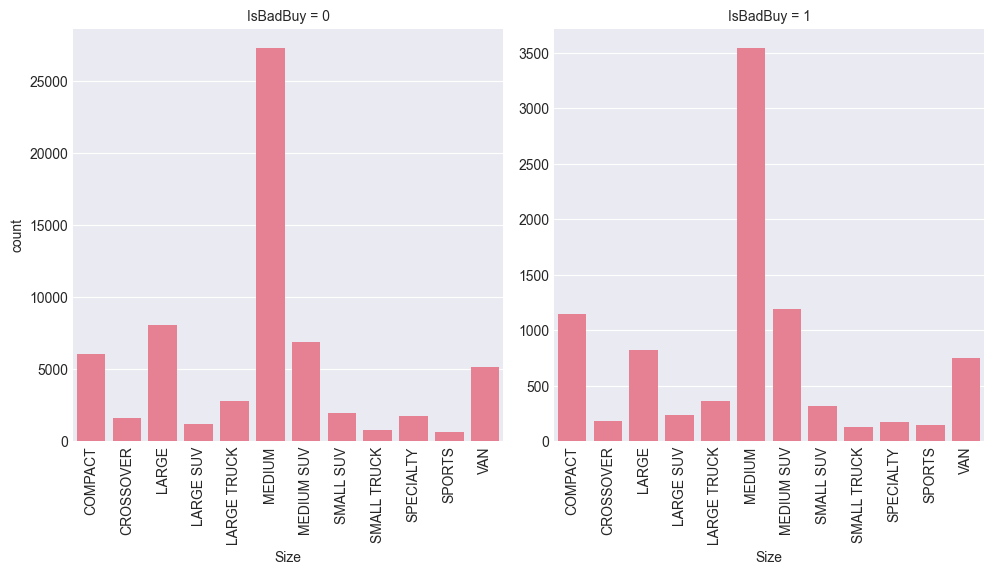

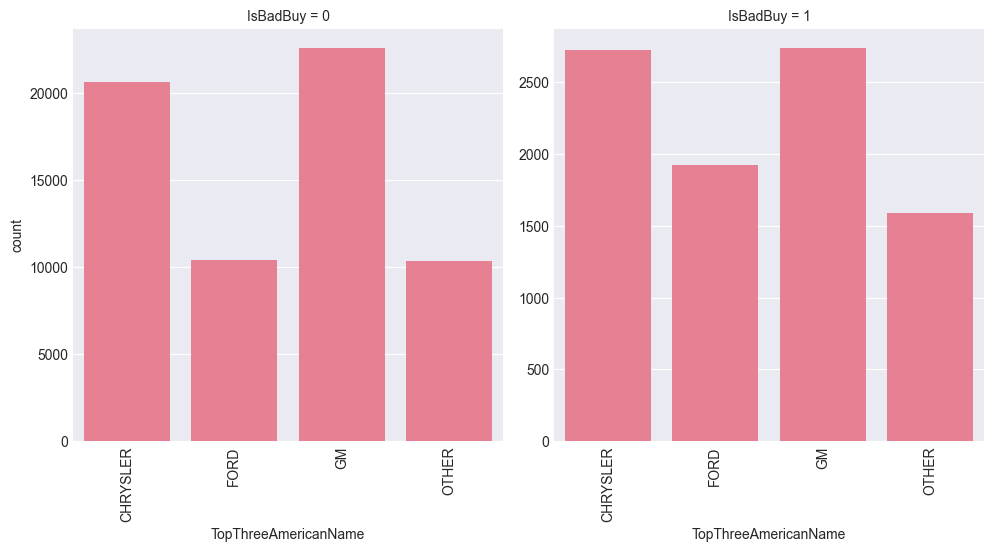

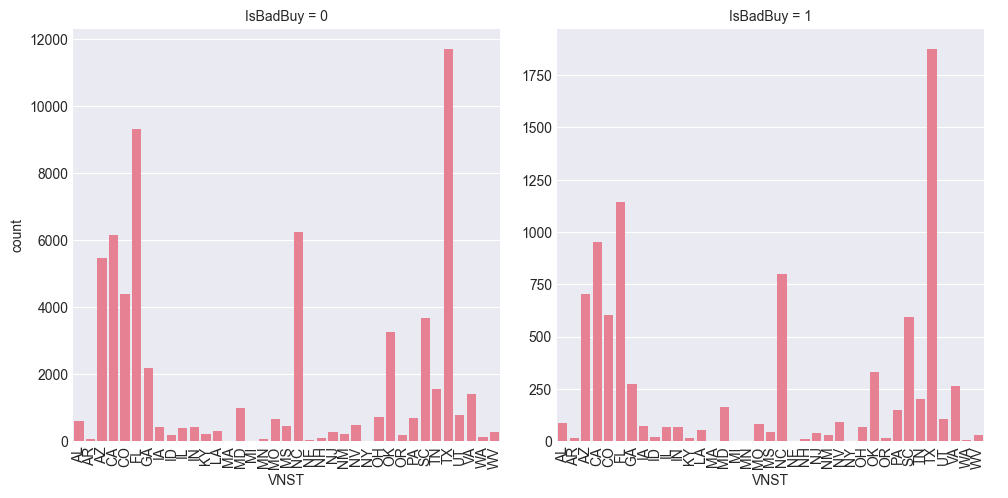

In [37]:
for col in cat_columns: 
    if col not in ['Model', 'Trim', 'SubModel']:
        order = sorted(df[col].dropna().unique())
        g = sns.catplot(x=col, kind='count', col='IsBadBuy', data=df, sharey=False, order=order)
        g.set_xticklabels(rotation=90)

По итогам анализа из-за низкого влияния на изменения таргета можно удалить следующие колонки (низкое влияние не означает, что признак точно нужно удалять, но я убираю те признаки, которые, на мой взгляд, не влияют на качество машины):
- VNST (слишком много значений, а влияние низкое, считаю, что названия аукциона будет достаточно для модели)
- Color (вряд ли цвет сильно влияет на то, сломается ли машина)

А вот, например, коробка передач, хоть и расрпеделена одинаково, исходя из здравого смысла и логики, может влиять на работоспособность машины -> это нужно учесть

In [38]:
df = df.drop(['VNST', 'Color'], axis=1) 

In [39]:
numeric_columns, cat_columns = get_column_types(df)

In [40]:
df.shape

(72983, 25)

Также видно, что MANUAL и Manual дублируются в столбце с коробкой предач, заменим:

In [41]:
df['Transmission'].unique()

<StringArray>
['AUTO', 'MANUAL', 'Manual']
Length: 3, dtype: str

In [42]:
df['Transmission'] = df['Transmission'].apply(lambda x: 'MANUAL' if x == 'Manual' else x)

## Итог

In [43]:
print(f'Сокращено признаков: {initially_df_len - df.shape[1]}')

Сокращено признаков: 9


# Реализация класса DecisionTreeClassifier and DecisionTreeRegressor

In [44]:
class BaseDecisionTree: 
    def __init__(self, max_depth=5, min_samples_split:int = 2):
        self.max_depth = max_depth 
        self.min_samples_split = min_samples_split 
        self._classes = None
        self.tree = None 
    
    def fit(self, X, y, randomized=False): 
        self.tree = self._grow_tree(X, y, depth=0, randomized=randomized)
        self._classes = np.sort(y.unique())
        return self
    
    def predict(self, X): 
        return np.array(
            [
                self._traverse(row, self.tree) 
                for _, row in X.iterrows()
            ]
        ) 
 
    def _grow_tree(self, X, y, depth, randomized=False): 
        if depth >= self.max_depth or len(y) < self.min_samples_split or len(y.unique()) == 1: 
            return self._make_leaf(y) 
        
        feature, threshold = self._best_split(X, y) if not randomized else self._best_random_split(X, y)
        
        if feature is None: 
            return self._make_leaf(y) 
        
        X_left, y_left, X_right, y_right = self._split(X, y, feature, threshold) 
        
        left = self._grow_tree(X_left, y_left, depth+1, randomized=randomized) 
        right = self._grow_tree(X_right, y_right, depth+1, randomized=randomized) 
        
        return {
            'type': 'node', 
            'feature': feature, 
            'threshold': threshold, 
            'left': left, 
            'right': right
        }

    def _best_random_split(self, X, y):
        best_features = None 
        best_threshold = None 
        best_error = np.inf 
        
        for feature in X.columns: 
            min_value = X[feature].min()
            max_value = X[feature].max()
            
            if min_value == max_value: 
                continue
            
            threshold = np.random.uniform(min_value, max_value)
            X_left, y_left, X_right, y_right = self._split(X, y, feature, threshold) 
            
            if len(y_left) == 0 or len(y_right) == 0: 
                continue 
            
            error = len(y_left) / len(y) * self._criterion(y_left) + len(y_right) / len(y) * self._criterion(y_right)
            
            if error < best_error: 
                best_error = error
                best_features = feature
                best_threshold = threshold
                
        return best_features, best_threshold

    def _best_split(self, X, y): 
        best_features = None 
        best_threshold = None 
        best_error = np.inf 
        
        for feature in X.columns: 
            values = np.sort(X[feature].unique())
            
            for i in range(1, len(values)): 
                threshold = (values[i-1] + values[i]) / 2
                
                X_left, y_left, X_right, y_right = self._split(X, y, feature, threshold) 
                
                if len(y_left) == 0 or len(y_right) == 0: 
                    continue
                
                error = len(y_left) / len(y) * self._criterion(y_left) + len(y_right) / len(y) * self._criterion(y_right)
                
                if error < best_error: 
                    best_error = error 
                    best_threshold = threshold 
                    best_features = feature 
                
        
        return best_features, best_threshold
    
    def _split(self, X, y, feature, threshold):
        left_mask = X[feature] <= threshold
        right_mask = X[feature] > threshold

        return (
            X[left_mask],
            y[left_mask],
            X[right_mask],
            y[right_mask]
        )
        
    def _traverse(self, row, node):
        if node['type'] == 'leaf': 
            return node['value'] 
        if row[node['feature']] <= node['threshold']: 
            return self._traverse(row, node["left"])
        else:
            return self._traverse(row, node["right"])
        
    def _criterion(self, y):
        raise NotImplementedError

    def _make_leaf(self, y):
        raise NotImplementedError
        

In [45]:
class my_DecisionTreeRegressor(BaseDecisionTree): 
    def _criterion(self, y):
        return np.mean((y - y.mean()) ** 2)

    def _make_leaf(self, y):
        return {
            "type": "leaf",
            "value": y.mean()
        }
        

In [46]:
class my_DecisionTreeClassifier(BaseDecisionTree):
    def _criterion(self, y):
        probs = y.value_counts(normalize=True)
        return 1 - np.sum(probs ** 2)
    
    def _make_leaf(self, y):
        probs = y.value_counts(normalize=True).to_dict()
        return {
            'type': 'leaf', 
            'value': y.mode()[0], 
            'probs': probs
        }
    
    def _traverse_proba(self, row, node):
        if node['type'] == 'leaf': 
            return node['probs'] 
        if row[node['feature']] <= node['threshold']: 
            return self._traverse_proba(row, node["left"])
        else:
            return self._traverse_proba(row, node["right"])
    
    def predict_proba(self, X): 
        probs = [] 
        
        for _, row in X.iterrows():
            leaf_probs = self._traverse_proba(row, self.tree)

            row_probs = [
                leaf_probs.get(cls, 0)
                for cls in self._classes
            ]
            
            probs.append(row_probs)
        
        return np.array(probs)
        

# Разбиение признаков

In [47]:
X_train, y_train, X_valid, y_valid, X_test, y_test = my_time_train_valid_test_split(df)
X_train, X_valid, X_test = X_train.drop('PurchDate', axis=1), X_valid.drop('PurchDate', axis=1), X_test.drop('PurchDate', axis=1)

# Кодирование признаков

## Сокращаю кол-во признаков

Фун-я, которая сокращает признаки за прогон

In [48]:
def cut_cat_features(df: pd.DataFrame, columns_list: list | np.ndarray | None = None) -> pd.DataFrame | None: 
    new_df = df.copy()
    print('Вы забыли отправить список колонок! Фун-я ничего сейчас ничего не делает\n')
    print('Изначальное кол-во признаков')
    for el in new_df.select_dtypes(include='object'): 
        print(f'Объект {el}, кол-во уникальных элементов: {len(new_df[el].unique())}')
    
    if columns_list:
        unpopular_names= []
        for col_name in columns_list: 
            for elem_name, count_elem in X_train[col_name].value_counts().sort_values(ascending=False).items(): 
                if count_elem <= 10: 
                    unpopular_names.append(elem_name)
            new_df[col_name] = new_df[col_name].apply(lambda x: 'Other' if x in unpopular_names else x)
            
        print('\nИтог')
        for el in new_df.select_dtypes(include='object'): 
            print(f'Объект {el}, кол-во уникальных элементов: {len(new_df[el].unique())}')
        
        return new_df

Признаки Make, Model, Trim, SubModel, Size будут закодированы TargetEncoder, но для начала проверим количество признаков у фичи

У этих колонок очень много различных признаков, некоторые из которых встречаются меньше 10 раз, считаю необходимым их заменить на класс 'Other', чтобы сократить шум

In [49]:
X_train = cut_cat_features(X_train, ['Model', 'Trim', 'SubModel'])

Вы забыли отправить список колонок! Фун-я ничего сейчас ничего не делает

Изначальное кол-во признаков
Объект Auction, кол-во уникальных элементов: 3
Объект Make, кол-во уникальных элементов: 31
Объект Model, кол-во уникальных элементов: 801
Объект Trim, кол-во уникальных элементов: 122
Объект SubModel, кол-во уникальных элементов: 663
Объект Transmission, кол-во уникальных элементов: 2
Объект Nationality, кол-во уникальных элементов: 4
Объект Size, кол-во уникальных элементов: 12
Объект TopThreeAmericanName, кол-во уникальных элементов: 4

Итог
Объект Auction, кол-во уникальных элементов: 3
Объект Make, кол-во уникальных элементов: 31
Объект Model, кол-во уникальных элементов: 257
Объект Trim, кол-во уникальных элементов: 72
Объект SubModel, кол-во уникальных элементов: 234
Объект Transmission, кол-во уникальных элементов: 2
Объект Nationality, кол-во уникальных элементов: 4
Объект Size, кол-во уникальных элементов: 12
Объект TopThreeAmericanName, кол-во уникальных элементов: 4


## Кодирование TargetEncoder + OneHot

In [50]:
cut_cat_features(X_train) # type: ignore

Вы забыли отправить список колонок! Фун-я ничего сейчас ничего не делает

Изначальное кол-во признаков
Объект Auction, кол-во уникальных элементов: 3
Объект Make, кол-во уникальных элементов: 31
Объект Model, кол-во уникальных элементов: 257
Объект Trim, кол-во уникальных элементов: 72
Объект SubModel, кол-во уникальных элементов: 234
Объект Transmission, кол-во уникальных элементов: 2
Объект Nationality, кол-во уникальных элементов: 4
Объект Size, кол-во уникальных элементов: 12
Объект TopThreeAmericanName, кол-во уникальных элементов: 4


In [51]:
ohe_cols = [col for col in cat_columns if X_train[col].nunique() <= 12]
target_cols = [col for col in cat_columns if X_train[col].nunique() > 12] 

In [52]:
preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ohe_cols), 
        ('TargetEncoder', TargetEncoder(smoothing=10.0), target_cols)
    ], remainder='passthrough'
)

In [53]:
preprocessor.fit(X_train, y_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OneHotEncoder', ...), ('TargetEncoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

In [54]:
X_train_encoded = preprocessor.transform(X_train)
X_valid_encoded = preprocessor.transform(X_valid)
X_test_encoded = preprocessor.transform(X_test)

In [55]:
ohe_feature_names = preprocessor.named_transformers_['OneHotEncoder'].get_feature_names_out(ohe_cols)
all_feature_names = list(ohe_feature_names) + target_cols + list(X_train.columns.drop([*cat_columns]))

In [56]:
X_train_encoded = pd.DataFrame(X_train_encoded, columns=all_feature_names, index=X_train.index)
X_valid_encoded = pd.DataFrame(X_valid_encoded, columns=all_feature_names, index=X_valid.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=all_feature_names, index=X_test.index)

In [57]:
X_train_encoded.head(1)

,Auction_ADESA,Auction_MANHEIM,Auction_OTHER,Transmission_AUTO,Transmission_MANUAL,Nationality_AMERICAN,Nationality_OTHER,Nationality_OTHER ASIAN,Nationality_TOP LINE ASIAN,Size_COMPACT,...,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,VehBCost,WarrantyCost
0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,7261.0,8857.0,8342.0,10066.0,8709.0,10331.0,9906.0,11657.0,6770.0,1389.0


# Поверка имплементированных моделей DecisionTreeReg/Class 

In [58]:
my_dt_model = my_DecisionTreeClassifier(max_depth=5, min_samples_split=10) 
my_dt_model.fit(X_train_encoded[:5000], y_train[:5000]) 

In [59]:
y_score = my_dt_model.predict_proba(X_valid_encoded)
gini = 2 * roc_auc_score(y_valid, y_score[:,1]) - 1
gini

0.29305099369274656

In [60]:
lib_dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=10)
lib_dt_model.fit(X_train_encoded[:5000], y_train[:5000]) 

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [61]:
y_lib_score = lib_dt_model.predict_proba(X_valid_encoded)
gini = 2 * roc_auc_score(y_valid, y_lib_score[:,1]) - 1
gini

0.3047723369024238

Лучше ли показатель gini у модели из библиотеки? Если да, то почему? 
Реализации оказались примерно схожими по коэффициенту gini, однако в большинстве случаев засчет внутренней оптимизации и гибкой настройке параметров библиотечная модель окажется лучше 

# Реализация класса My_RandomForestClassifier

In [62]:
class my_RandomForestClassifier: 
    def __init__(self, n_estimators=10, max_depth=5, min_samples_split=10, max_features: int | str = 10, bootstrap=True, random_state=21): 
        self.n_estimators = n_estimators 
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split 
        self.max_feature = max_features
        self.random_state = random_state 
        self.bootstrap = bootstrap 
        
        self.trees = [] 
        self.features_per_tree = [] 
        self._classes = None 
        self.rng = np.random.default_rng(random_state)
        
    def _sample_rows(self, X, y): 
        n_samples = len(X) 
        
        if self.bootstrap: 
            row_idx = self.rng.choice(n_samples, size=n_samples, replace=True)
        else: 
            row_idx = np.arange(n_samples) 
        
        X_sample = X.iloc[row_idx] 
        y_sample = y.iloc[row_idx] 
        
        return X_sample, y_sample

    def _sample_features(self, X): 
        n_feature = X.shape[1] 
        
        if self.max_feature is None: 
            n_selected = int(np.sqrt(n_feature)) 
        elif isinstance(self.max_feature, str): 
            if self.max_feature == "sqrt":
                n_selected = int(np.sqrt(n_feature))
            elif self.max_feature == "log2":
                n_selected = int(np.log2(n_feature))
            else:
                raise ValueError("max_features must be None, int, 'sqrt' or 'log2'")
        else:
            n_selected = self.max_feature
        
        n_selected = max(1, min(n_selected, n_feature))
        feature_idx = self.rng.choice(n_feature, size=n_selected, replace=False) 
        selected_features = X.columns[feature_idx]
        return selected_features 
    
    def fit(self, X, y): 
        self.trees = [] 
        self.features_per_tree = [] 
        self._classes = np.sort(y.unique()) 
        
        for _ in range(self.n_estimators): 
            X_sample, y_sample = self._sample_rows(X, y) 
            selected_features = self._sample_features(X_sample) 
            
            tree = my_DecisionTreeClassifier(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            tree.fit(X_sample[selected_features], y_sample) 
            
            self.trees.append(tree) 
            self.features_per_tree.append(selected_features) 
            
        return self
    
    def predict_proba(self, X): 
        all_probas = [] 
        
        for tree, fetures in zip(self.trees, self.features_per_tree): 
            tree_proba = tree.predict_proba(X[fetures]) 
            all_probas.append(tree_proba) 
        
        mean_proba = np.mean(all_probas, axis=0) 
        return mean_proba 

    def predict(self, X): 
        proba = self.predict_proba(X) 
        pred_idx = np.argmax(proba, axis=1) 
        return self._classes[pred_idx]    
        
        

In [63]:
my_forest = my_RandomForestClassifier(
    n_estimators=10,
    max_depth=7,
    min_samples_split=20,
    max_features="sqrt",
    bootstrap=True,
    random_state=21
)

my_forest.fit(X_train_encoded[:5000], y_train[:5000])

In [64]:
y_my_forest_score = my_forest.predict_proba(X_valid_encoded)
gini = 2 * roc_auc_score(y_valid, y_my_forest_score[:,1]) - 1
gini

0.2998934344599826

# Реализация класса my_GBDT

In [65]:
class my_GBDT: 
    def __init__(self, max_depth=3, number_of_trees=10, max_features=None, learning_rate=0.1, random_state=21):
        self.max_depth = max_depth
        self.number_of_trees = number_of_trees
        self.max_features = max_features
        self.learning_rate = learning_rate
        self.random_state = random_state

        self.trees = []
        self.features_per_tree = []
        self.base_prediction = None
        self._classes = None
        self.rng = np.random.default_rng(random_state)
        
    def _sigmoid(self, x):
        x = np.clip(x, -500, 500) 
        return 1 / (1 + np.exp(-x)) 
    
    def _logit(self, p): 
        p = np.clip(p, 1e-15, 1 - 1e-15) 
        return np.log(p / (1-p)) 
    
    def _sample_features(self, X): 
        n_feature = X.shape[1] 
        
        if self.max_features is None: 
            n_selected = int(np.sqrt(n_feature)) 
        elif isinstance(self.max_features, str): 
            if self.max_features == "sqrt":
                n_selected = int(np.sqrt(n_feature))
            elif self.max_features == "log2":
                n_selected = int(np.log2(n_feature))
            else:
                raise ValueError("max_features must be None, int, 'sqrt' or 'log2'")
        else:
            n_selected = self.max_features
        
        n_selected = max(1, min(n_selected, n_feature))
        feature_idx = self.rng.choice(n_feature, size=n_selected, replace=False) 
        selected_features = X.columns[feature_idx]
        return selected_features 
    
    def fit(self, X, y): 
        X = X.copy() 
        y = pd.Series(y).copy() 
        
        self._classes = np.sort(y.unique()) 
        if len(self._classes) != 2: 
            raise ValueError('Поддерживается только бинарная классификация') 
        
        y_bin = (y == self._classes[1]).astype(float) 
        
        p0 = y_bin.mean()
        self.base_prediction = self._logit(p0) 
        
        self.trees = [] 
        self.features_per_tree = [] 
        
        F = np.full(len(X), self.base_prediction, dtype=float)
        
        for _ in range(self.number_of_trees): 
            p = self._sigmoid(F) 
            
            residual = y_bin - p 
            selected_features = self._sample_features(X) 
            
            tree = my_DecisionTreeRegressor(max_depth=self.max_depth, min_samples_split=2) 
            tree.fit(X[selected_features], residual)
            
            tree_pred = tree.predict(X[selected_features])
            F+= self.learning_rate * tree_pred 
            
            self.trees.append(tree) 
            self.features_per_tree.append(selected_features) 
            
        return self
        
    def predict_proba(self, X): 
        X = X.copy() 
        
        F = np.full(len(X), self.base_prediction, dtype=float) 
        
        for tree, fetures in zip(self.trees, self.features_per_tree): 
            tree_pred = tree.predict(X[fetures]) 
            F += self.learning_rate * tree_pred 
            
        p1 = self._sigmoid(F) 
        p0 = 1 - p1 
        
        return np.column_stack([p0, p1]) 

    def predict(self, X): 
        proba = self.predict_proba(X) 
        pred_idx = (proba[:, 1] >= 0.5).astype(int)
        return self._classes[pred_idx] 
    
    

In [66]:
my_gbdt = my_GBDT(max_depth=7)

In [67]:
my_gbdt.fit(X_valid_encoded[:5000], y_valid[:5000])

In [68]:
y_my_gbdt_score = my_gbdt.predict_proba(X_valid_encoded)
gini = 2 * roc_auc_score(y_valid, y_my_gbdt_score[:,1]) - 1
gini

0.3505373050178875

# Применение библиотечных LightGBM, Catboost, XGBoost для задачи

Ключевые различия и описание каждой реализации: 
* XGBoost - классический бустинг, похож на GBDT с настраиваемыми и интерпретируемыми гиперпараметрами, часто используется как baseline. Имеет режим DART - dropout при обучении деревьев (когда на предсказаниях временно отключается часть уже построенных деревьев, чтобы уменьшить переобучение и сделать обощающую способность модели более устойчивой)
* LightGBM - ориентирован на скорость и эффективность на больших табличных данных, но более склонен к переобучению
* CatBoost - единственная модель, которая работает с кат.признаками под капотом. Показывает себя лучше остальных в датасетах с большим кол-вом значащих кат.величин 

In [83]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(X_train_encoded, y_train)

lgbm_valid_proba = lgbm.predict_proba(X_valid_encoded)[:, 1]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2794, number of negative: 21533
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002844 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3324
[LightGBM] [Info] Number of data points in the train set: 24327, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.114852 -> initscore=-2.042112
[LightGBM] [Info] Start training from score -2.042112
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

In [84]:
lgbm_valid_gini = gini_score(y_valid, lgbm_valid_proba)
print("Gini на LightGBM:", lgbm_valid_gini)

Gini на LightGBM: 0.44834549218327213


In [ ]:
cat_features = X_train.select_dtypes(include="object").columns.tolist()

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    verbose=100
)

cat_valid_proba = cat_model.predict_proba(X_valid)[:, 1]
cat_valid_gini = gini_score(y_valid, cat_valid_proba)


0:	test: 0.6936344	best: 0.6936344 (0)	total: 67.2ms	remaining: 33.5s
100:	test: 0.7404427	best: 0.7404427 (100)	total: 1.76s	remaining: 6.95s
200:	test: 0.7419909	best: 0.7420178 (199)	total: 3.3s	remaining: 4.92s
300:	test: 0.7407838	best: 0.7428022 (224)	total: 4.91s	remaining: 3.24s
400:	test: 0.7393650	best: 0.7428022 (224)	total: 6.56s	remaining: 1.62s
499:	test: 0.7357443	best: 0.7428022 (224)	total: 8.17s	remaining: 0us

bestTest = 0.7428021516
bestIteration = 224

Shrink model to first 225 iterations.


In [86]:
print("Gini на CatBoost:", cat_valid_gini)

Gini на CatBoost: 0.48560430319523995


In [87]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train_encoded, y_train)

xgb_valid_proba = xgb.predict_proba(X_valid_encoded)[:, 1]


In [88]:
xgb_valid_gini = gini_score(y_valid, xgb_valid_proba)
print("XGBoost valid Gini:", xgb_valid_gini)

XGBoost valid Gini: 0.45696519514146194


## Вывод 
Лучшей моделью оказалась CatBoost, так как в датасете имеется большое число значащих кат. признаков, которые CatBoost умеет обрабатывать под капотом без грубой категоризации OHE или TargetEncoding

# Выбор лучшей модели
Лучшей моделью стал CatBoost из-за большого кол-ва кат.признаков в наборе

In [89]:
print(f'Gini на валидации {cat_valid_gini}')

Gini на валидации 0.48560430319523995


In [90]:
cat_test_proba = cat_model.predict_proba(X_test)[:, 1]
cat_test_gini = gini_score(y_test, cat_test_proba)

print(f'Gini на тесте {cat_test_gini}')

Gini на тесте 0.4976390386817413


In [91]:
cat_train_proba = cat_model.predict_proba(X_train)[:, 1]
cat_train_gini = gini_score(y_train, cat_train_proba)

print(f'Gini на трейне {cat_train_gini}')

Gini на трейне 0.560832599967003


## Вывод: 
Между valid и test значение Gini не падает сильно - это означает, что у модели хорошая обобщающая способность -> модель не переобучилась 